# Day 39 — Kernel PCA, LLE & Dimensionality Reduction Review

- Understand why ordinary PCA cannot capture nonlinear structure.
- Learn Kernel PCA and the role of kernels.
- Tune Kernel PCA hyperparameters.
- Understand reconstruction / inverse transform.
- Learn Locally Linear Embedding (LLE).
- Compare PCA, Kernel PCA, LLE, t-SNE and MDS.

## 1. Imports and setup

We will use small synthetic datasets so that the geometry of dimensionality reduction is easy to visualize.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_swiss_roll, make_s_curve
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import LocallyLinearEmbedding, TSNE, MDS
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True


## 2. Why ordinary PCA struggles with nonlinear manifolds

PCA finds a linear projection that preserves as much variance as possible.

For a curved manifold such as the **Swiss roll**, a linear projection can flatten different parts of the manifold on top of each other.

**Key idea:** PCA is excellent for approximately linear structure, but nonlinear dimensionality reduction methods are often better for curved manifolds.

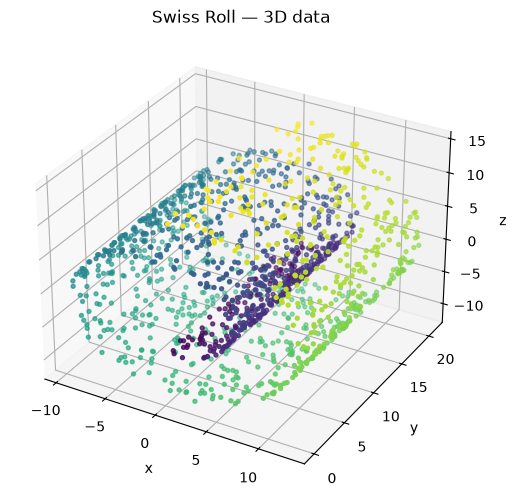

In [2]:
X, color = make_swiss_roll(n_samples=1500, noise=0.05, random_state=42)

fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, s=8)
ax.set_title("Swiss Roll — 3D data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()


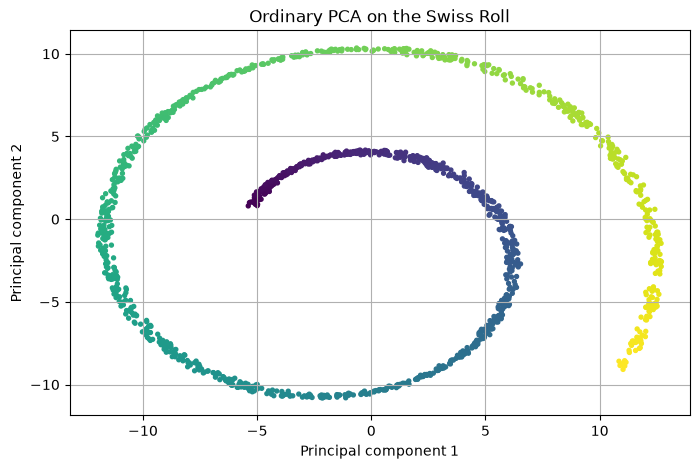

Explained variance ratio: [0.40740804 0.30603887]
Total explained variance: 0.7134469111173705


In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=color, s=8)
plt.title("Ordinary PCA on the Swiss Roll")
plt.xlabel("Principal component 1")
plt.ylabel("Principal component 2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())


## 3. Kernel PCA

**Kernel PCA (kPCA)** applies the kernel trick to PCA.

Instead of explicitly transforming the data into a high-dimensional feature space, it works with a **kernel matrix**.

Common kernels:
- `linear`
- `poly`
- `rbf`
- `sigmoid`

For nonlinear manifolds, the **RBF kernel** is often a strong starting point.

Important hyperparameters:
- `gamma` — controls the influence/radius of individual training examples for RBF.
- `degree` — polynomial degree for the polynomial kernel.
- `coef0` — independent term for some kernels.
- `n_components` — target dimension.

There is no universally best kernel; validation and the downstream task matter.

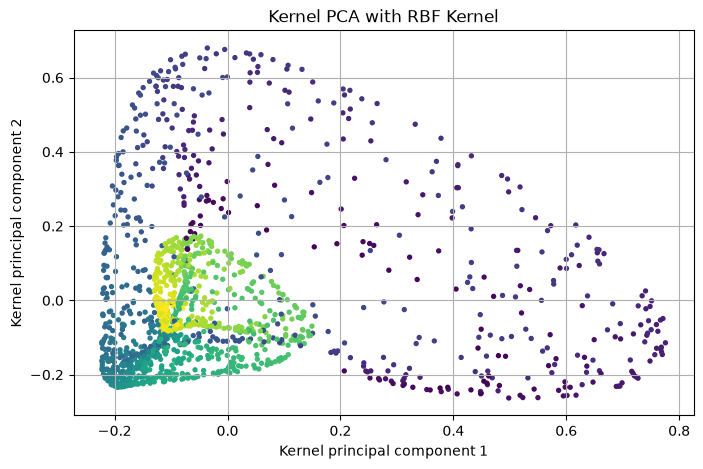

In [4]:
kpca_rbf = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.04
)

X_kpca = kpca_rbf.fit_transform(X)

plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=color, s=8)
plt.title("Kernel PCA with RBF Kernel")
plt.xlabel("Kernel principal component 1")
plt.ylabel("Kernel principal component 2")
plt.show()


### Experiment: change `gamma`

Try values such as:

```python
gamma = 0.01
gamma = 0.04
gamma = 0.1
gamma = 1
```

**Observation to look for:**  
A small gamma produces a broader notion of similarity; a large gamma makes similarity much more local. Extreme values can produce poor embeddings.

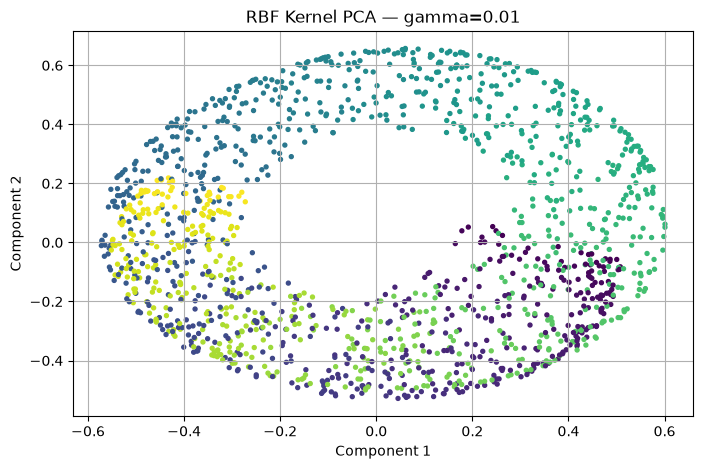

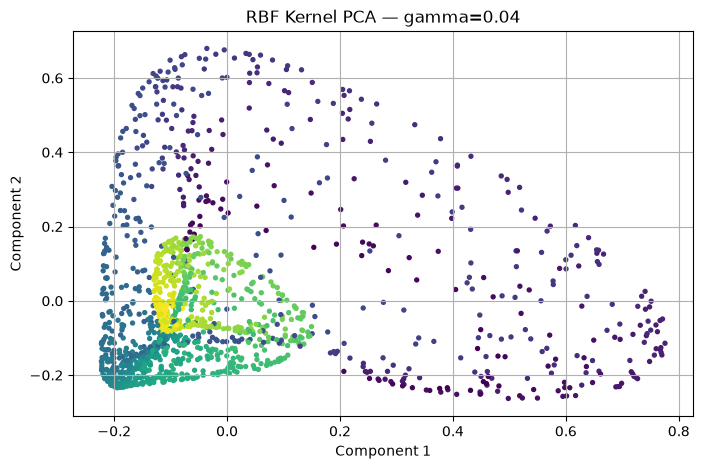

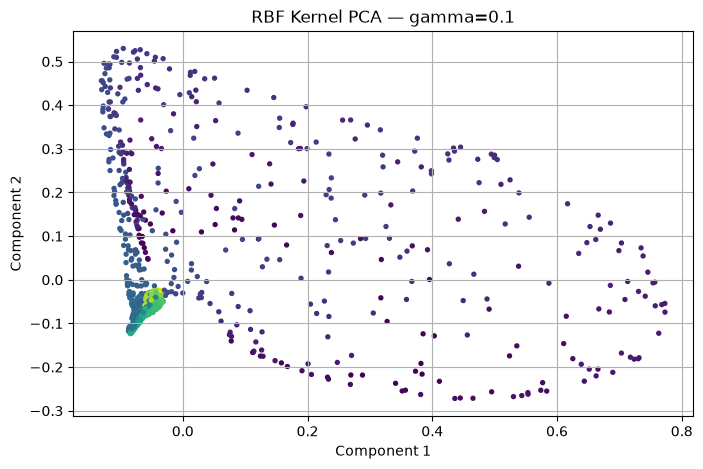

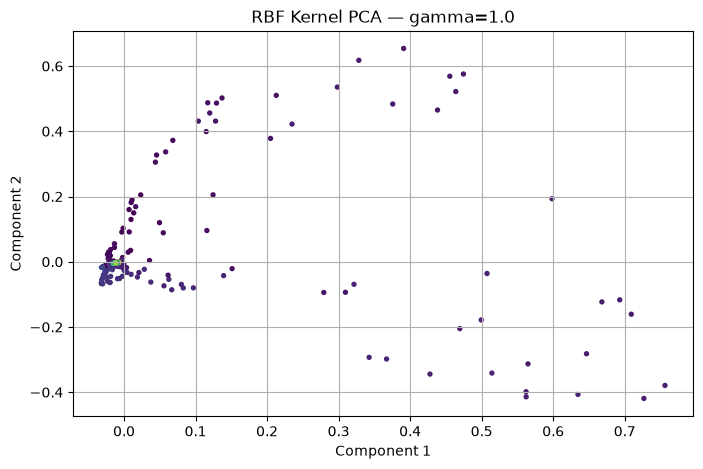

In [5]:
gammas = [0.01, 0.04, 0.1, 1.0]

for gamma in gammas:
    embedding = KernelPCA(n_components=2, kernel="rbf", gamma=gamma).fit_transform(X)
    plt.figure()
    plt.scatter(embedding[:, 0], embedding[:, 1], c=color, s=8)
    plt.title(f"RBF Kernel PCA — gamma={gamma}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()


## 4. Kernel selection

A practical approach:

1. Start with a linear model / ordinary PCA baseline.
2. Try RBF when the structure appears nonlinear.
3. Try polynomial if polynomial-like interactions make sense.
4. Tune kernel hyperparameters using a meaningful downstream objective.
5. Validate on held-out data.

**Important:** dimensionality reduction is not automatically evaluated by how pretty a 2D plot looks. For supervised problems, evaluate how well the reduced representation supports the final predictive task.

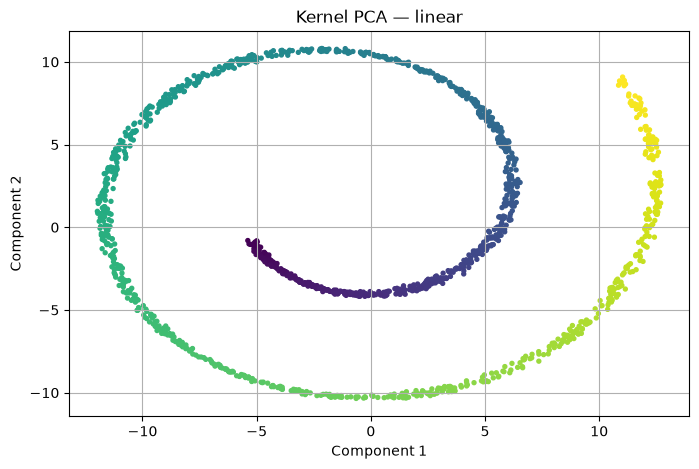

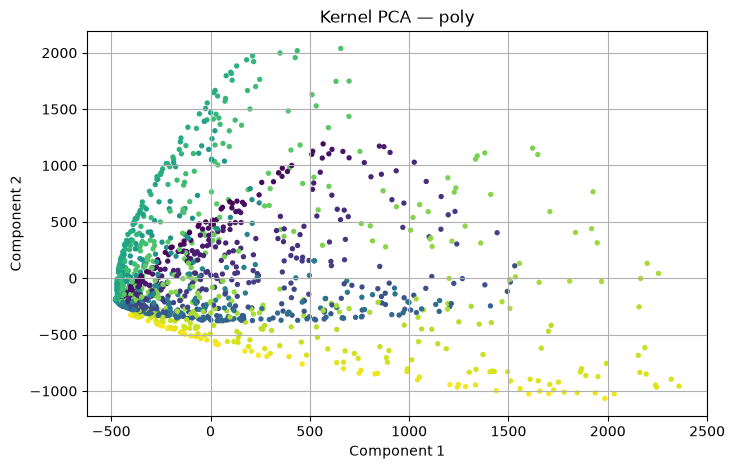

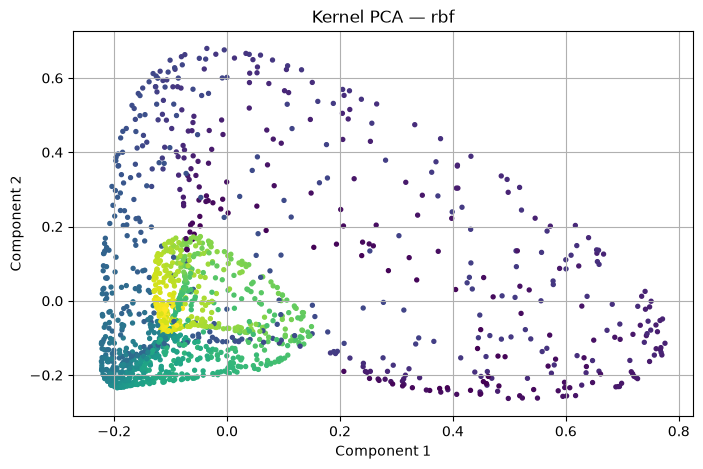

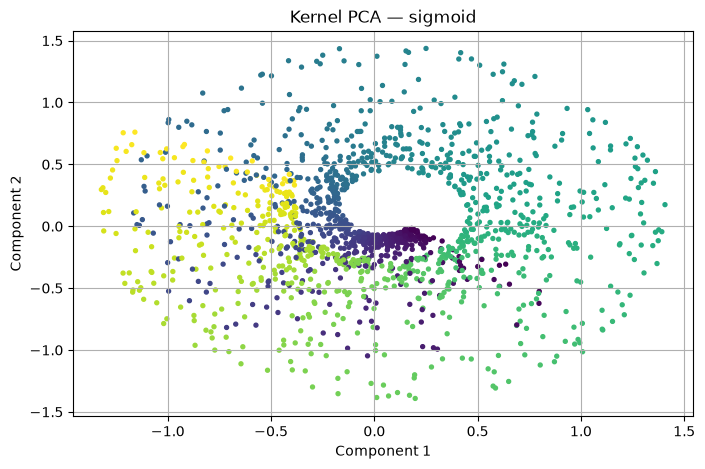

In [6]:
for kernel, params in [
    ("linear", {}),
    ("poly", {"degree": 3, "coef0": 1}),
    ("rbf", {"gamma": 0.04}),
    ("sigmoid", {"gamma": 0.04, "coef0": 1}),
]:
    model = KernelPCA(n_components=2, kernel=kernel, **params)
    Z = model.fit_transform(X)

    plt.figure()
    plt.scatter(Z[:, 0], Z[:, 1], c=color, s=8)
    plt.title(f"Kernel PCA — {kernel}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()


## 5. Kernel PCA hyperparameter tuning

For a real ML pipeline, tune hyperparameters using a downstream score rather than visual appearance alone.

Below is a small classification example using Kernel PCA followed by logistic regression.

The exact score is less important here than the workflow:

**Scaler → dimensionality reduction → estimator → GridSearchCV**.

In [7]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression

X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("kpca", KernelPCA(n_components=2, kernel="rbf")),
    ("logreg", LogisticRegression(max_iter=2000))
])

param_grid = {
    "kpca__gamma": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0],
    "logreg__C": [0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_moons, y_moons)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)


Best parameters: {'kpca__gamma': 3.0, 'logreg__C': 10}
Best CV accuracy: 0.906


## 6. Kernel PCA and reconstruction / inverse transform

Kernel PCA can be used with an inverse transform when configured with:

```python
fit_inverse_transform=True
```

This allows us to approximately map the reduced representation back toward the original feature space.

The reconstruction quality can help select hyperparameters in **unsupervised** settings.

Note that inverse reconstruction for Kernel PCA is an approximation; it is not the same as the exact inverse of ordinary PCA.

In [8]:
kpca_inverse = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.04,
    fit_inverse_transform=True
)

X_reduced = kpca_inverse.fit_transform(X)
X_reconstructed = kpca_inverse.inverse_transform(X_reduced)

reconstruction_mse = np.mean((X - X_reconstructed) ** 2)

print("Reconstruction MSE:", reconstruction_mse)


Reconstruction MSE: 32.49865039361605


## 7. Locally Linear Embedding (LLE)

**Locally Linear Embedding** is a manifold learning technique.

Main intuition:

1. Find each point's nearest neighbors.
2. Represent each point as a weighted combination of its neighbors.
3. Find a lower-dimensional representation that preserves those local relationships.

LLE is especially useful when the data lies on a nonlinear manifold and local geometry is more important than global linear variance.

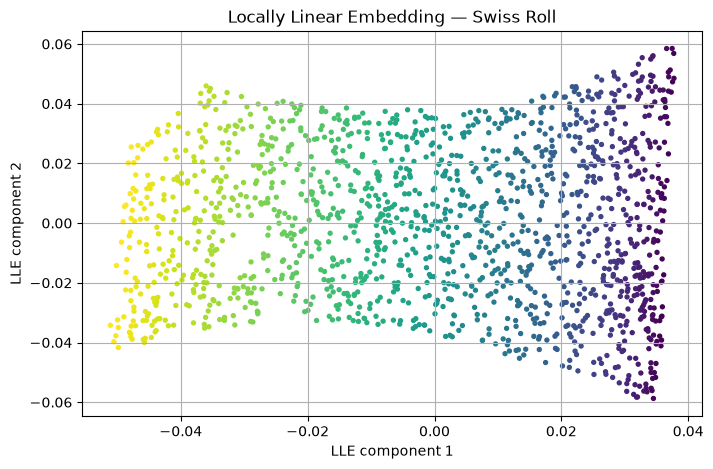

Reconstruction error: 1.0301220480499987e-07


In [9]:
lle = LocallyLinearEmbedding(
    n_components=2,
    n_neighbors=10,
    random_state=42
)

X_lle = lle.fit_transform(X)

plt.scatter(X_lle[:, 0], X_lle[:, 1], c=color, s=8)
plt.title("Locally Linear Embedding — Swiss Roll")
plt.xlabel("LLE component 1")
plt.ylabel("LLE component 2")
plt.show()

print("Reconstruction error:", lle.reconstruction_error_)


### Experiment: change `n_neighbors`

Try:

- 5
- 10
- 20
- 50

The number of neighbors controls how much local structure LLE considers.

Too few neighbors can make the representation unstable; too many can make the method less local.

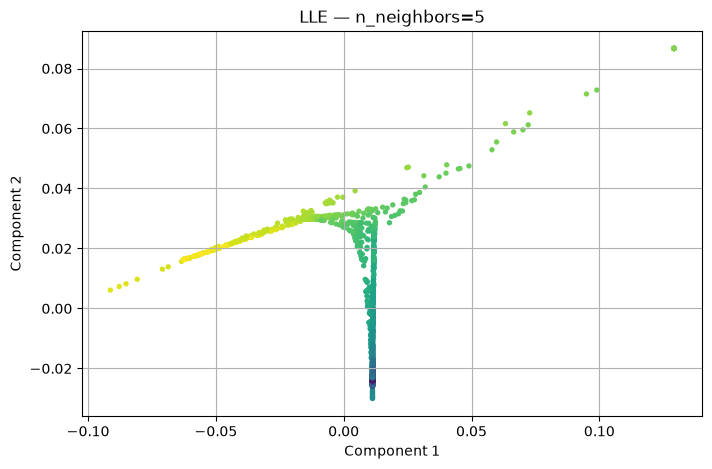

n_neighbors=5, reconstruction error=0.000000


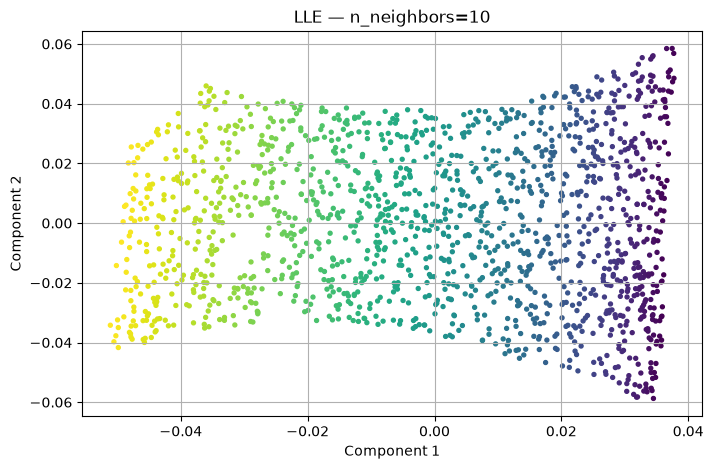

n_neighbors=10, reconstruction error=0.000000


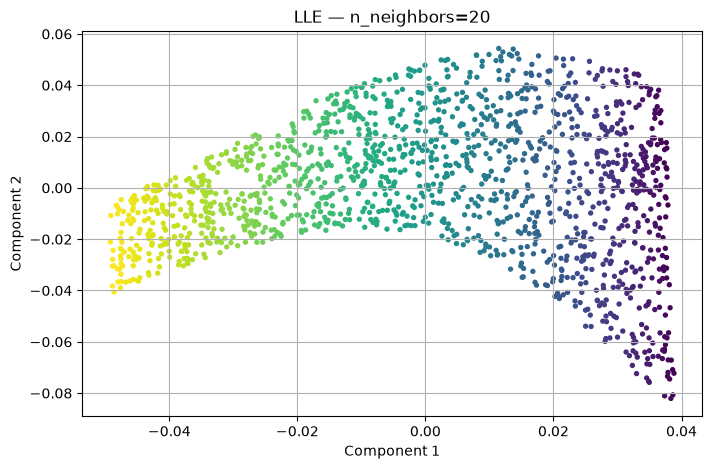

n_neighbors=20, reconstruction error=0.000000


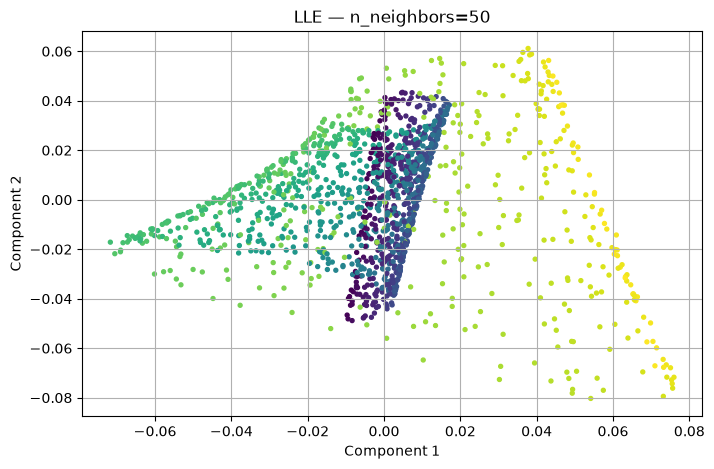

n_neighbors=50, reconstruction error=0.000001


In [10]:
for n_neighbors in [5, 10, 20, 50]:
    lle_model = LocallyLinearEmbedding(
        n_components=2,
        n_neighbors=n_neighbors,
        random_state=42
    )
    Z = lle_model.fit_transform(X)

    plt.figure()
    plt.scatter(Z[:, 0], Z[:, 1], c=color, s=8)
    plt.title(f"LLE — n_neighbors={n_neighbors}")
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.show()

    print(
        f"n_neighbors={n_neighbors}, "
        f"reconstruction error={lle_model.reconstruction_error_:.6f}"
    )


## 8. Other dimensionality-reduction techniques

### t-SNE
- Primarily designed for visualization.
- Preserves local neighborhood relationships well.
- Often produces visually separated clusters.
- Distances between clusters can be misleading.
- Results can depend strongly on hyperparameters and random initialization.
- Usually not the first choice for a production preprocessing pipeline.

### MDS
- Multidimensional Scaling attempts to preserve pairwise distances.
- Useful when preserving distance relationships is important.

### PCA
- Linear.
- Fast and deterministic for a fixed setup.
- Strong baseline for many datasets.

### Kernel PCA
- Nonlinear extension of PCA using kernels.
- Can uncover nonlinear structure.
- Kernel and hyperparameter selection matter.

### LLE
- Manifold-learning method based on local neighborhood reconstruction.
- Useful when local geometry is informative.